In [1]:
#%config InlineBackend.figure_formats=['svg']
from src.Utils import plot_traces, save_results, get_means
from src.Dataset import dataset_TES
from src.ExistingAlgorithms import max_value, area, sklearn_available
from src.ParametricUMAP import load_pumap
from src.GaussianMixture import gaussian_mixture

from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.manifold import Isomap, TSNE

import umap
import torch

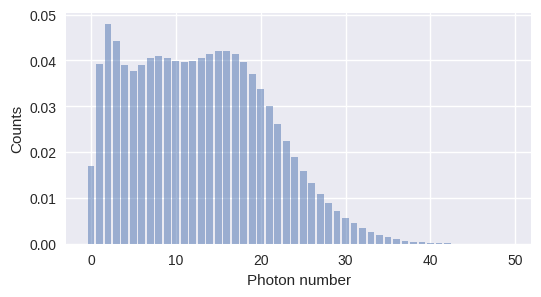

(30550, 350)

In [2]:
weights = [0.0003478958721172963, 0.0003456379713743067, 0.0003744276723215052, 2.7560595871623853e-07,
           5.1048808392493295e-18, 0.28842984940480537, 0.9999999999999999, 0.4483193456686096,
           0.34462236788026945, 0.42745454124885873, 6.426683431466243e-24, 3.0632312612371824e-29, 0.4770426849308018]

path_save = 'src/Results TES (Uniform)/Low Dimension'
path_results = 'src/Results TES (Uniform)'

data_train, data_test, expected_prob, db_train, db_test = dataset_TES(weights = weights,
                                                                      signal_size = 8192,
                                                                      interval = [0,350],#270],
                                                                      order_dB = False,
                                                                      normalize = True,
                                                                      plot_expected = True,
                                                                      plot_traces = False,
                                                                      n_photon_number = 50,
                                                                      return_db = True)

data_train.shape

### Max Value

In [3]:
X_l_MAX = max_value(data_test, filtering=True)

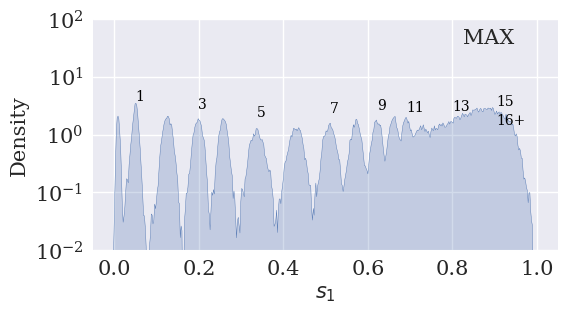

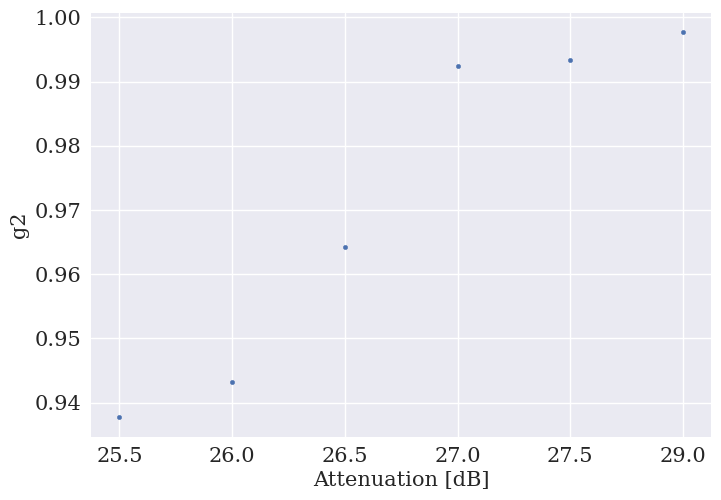

In [4]:
name_method = 'MAX'
#condition = X_l_MAX[:,0] < 0.8
gm = gaussian_mixture(X_l_MAX,
                      data_test,
                      means_init = get_means(name_method),
                      number_cluster = 17,
                      tol = 1e-4,
                      cluster_iter = 10,
                      info_sweep = 0,
                      plot_sweep = True,
                      dpi = 100)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False,
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

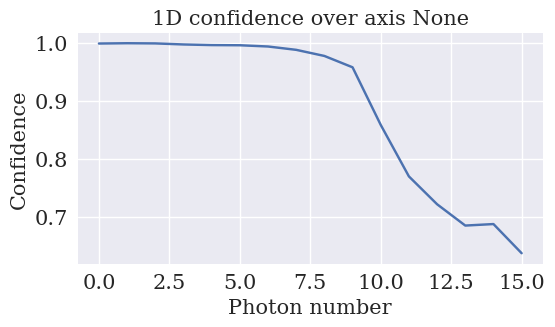

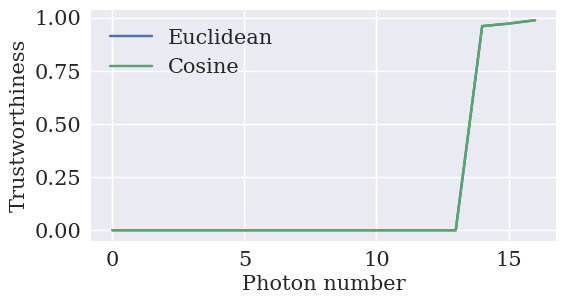

In [5]:
gm.plot_confidence_1d(expected_prob=expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Area

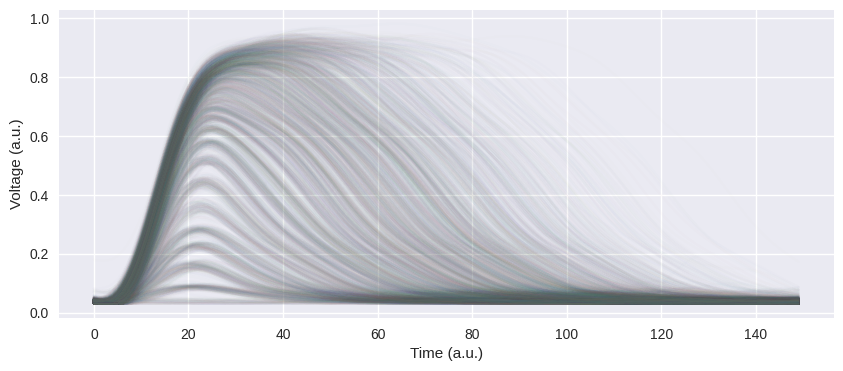

In [6]:
X_l_AREA  = area(data_test[:,:150], filtering = True, plot_filter = True, threshold = 0.03, critical_frequency = 0.1)

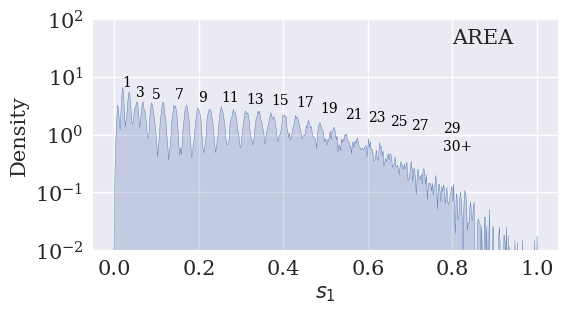

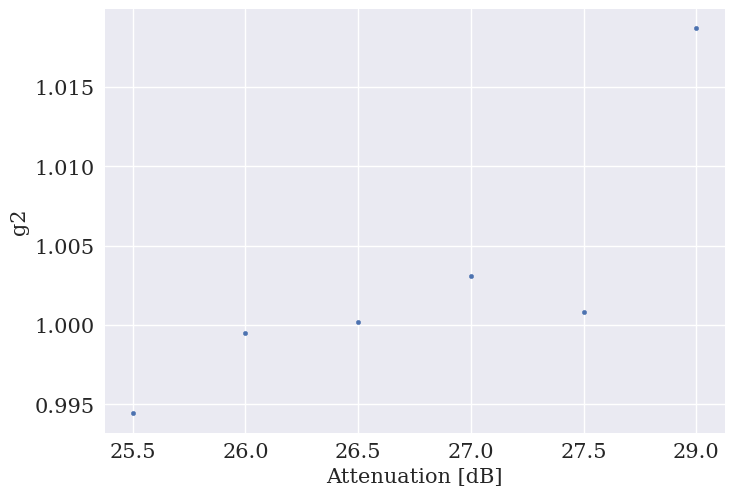

In [7]:
name_method = 'AREA'
gm = gaussian_mixture(X_l_AREA,
                      data_test,#[condition],
                      number_cluster = 31,
                      cluster_iter = 3,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

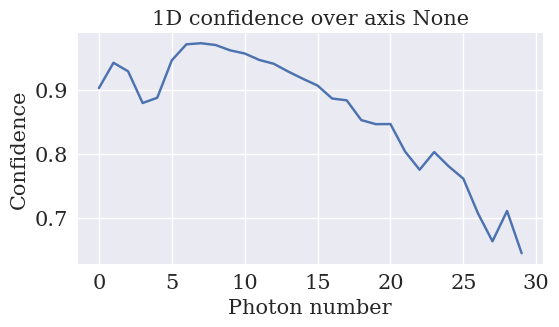

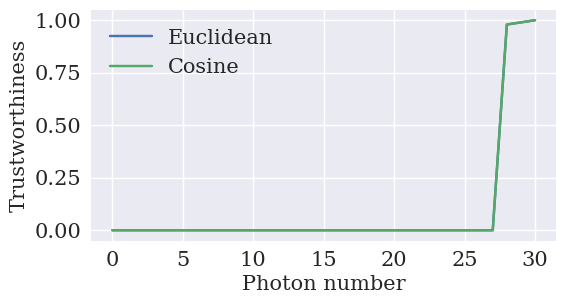

In [8]:
gm.plot_confidence_1d(expected_prob = expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Principal Component Analysis (PCA)

In [3]:
X_l_PCA = sklearn_available(data_train, data_test, path_save, PCA, n_components=1)

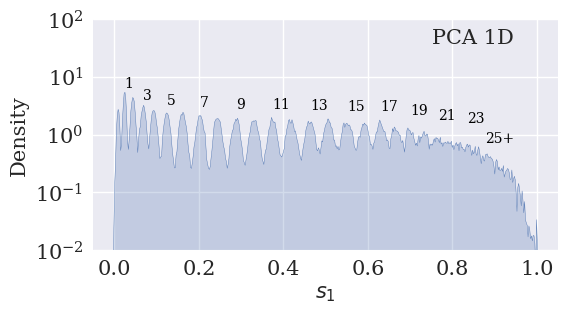

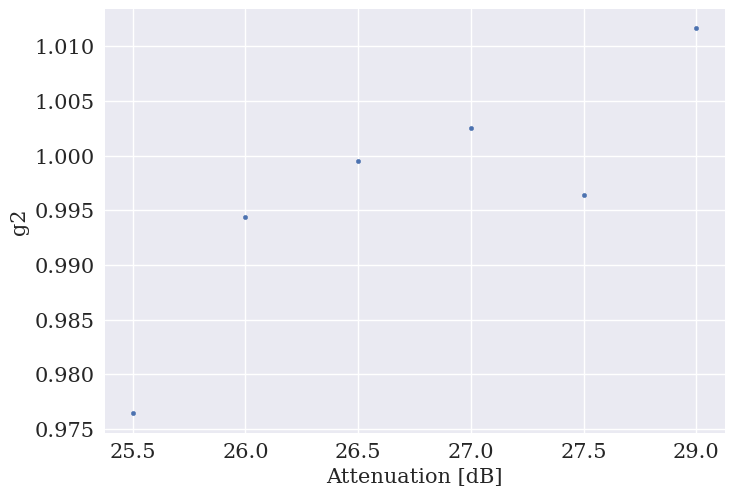

In [4]:
name_method = 'PCA 1D'
gm = gaussian_mixture(X_l_PCA,
                      data_test,
                      number_cluster = 26,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = False,
                      latex = False)

gm.plot_density(bw_adjust = 0.03,
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

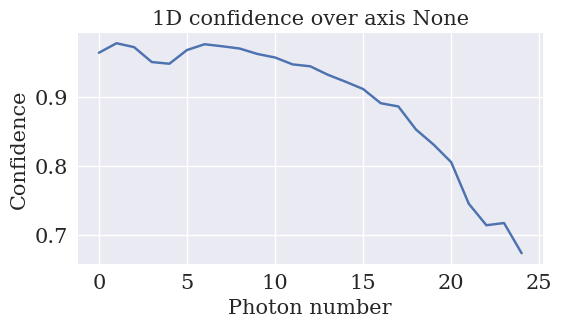

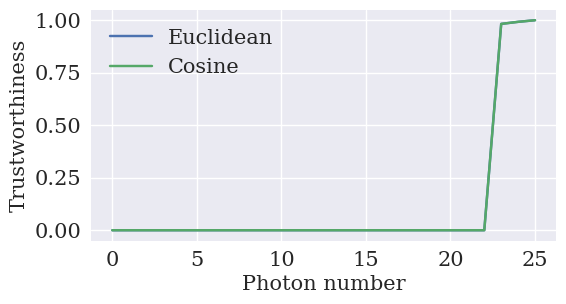

In [11]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [4]:
X_l_PCA = sklearn_available(data_train, data_test, path_save, PCA, n_components = 2)

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


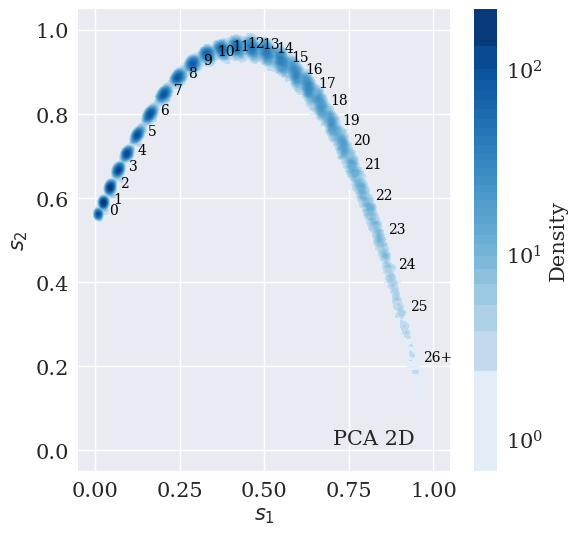

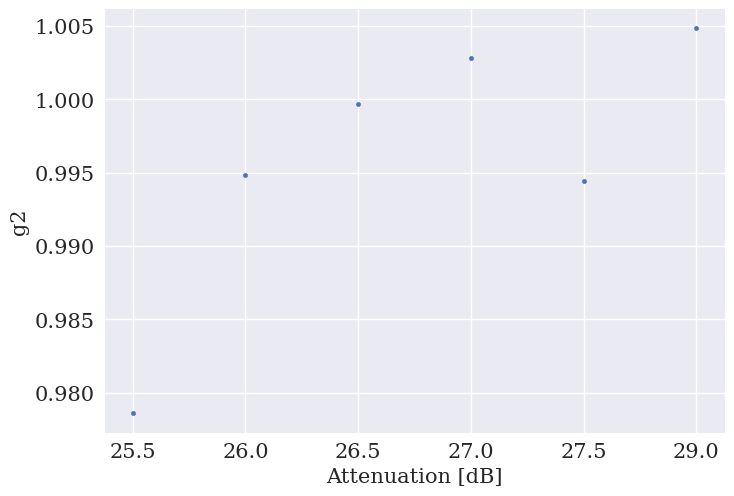

In [5]:
name_method = 'PCA 2D'
gm = gaussian_mixture(X_l_PCA,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path_results),
                      tol = 1e-4)

gm.plot_density(bw_adjust = 0.1,
                plot_gaussians = False,
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

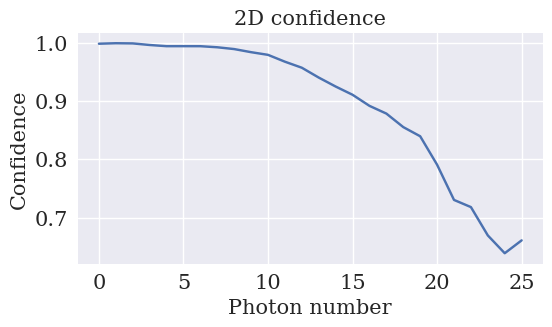

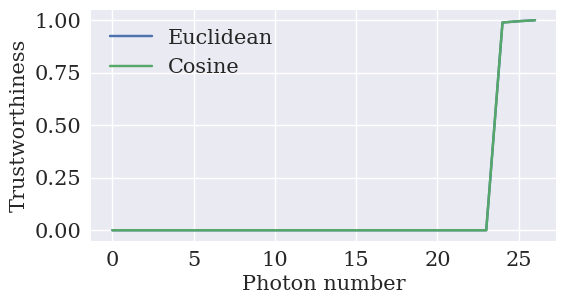

In [14]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Polynomial)

In [15]:
X_l_KPCA_P = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2, kernel="poly", gamma=1, degree = 2)

In [16]:
#name_method = 'KPCA Pol'
#gm = gaussian_mixture(X_l_KPCA_P,
#                      data_test,
#                      number_cluster = 27,
#                      cluster_iter = 20,
#                      means_init = None,#get_means(name_method, path_results),
#                      tol = 1e-3,
#                      info_sweep = 1,
#                      plot_sweep = True)

#gm.plot_density(bw_adjust = 0.1,
#                bw_adjust_x = 0.05,
#                bw_adjust_y = 0.05)
#gm.plot_cluster(plot_kde = True, bw_adjust = 0.1)
#gm.plot_traces()
#gm.plot_traces_average()

In [17]:
#gm.plot_confidence_1d(axis = 0) 
#gm.plot_confidence_2d()
#gm.plot_trustworthiness()
#save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Radial basis function)

In [18]:
X_l_KPCA_RBF = sklearn_available(data_train, data_test, path_save, KernelPCA, n_components = 2, kernel="rbf", gamma = 0.5) 

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


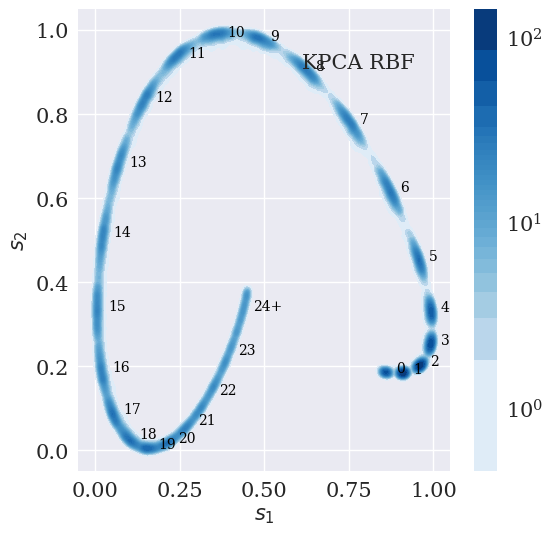

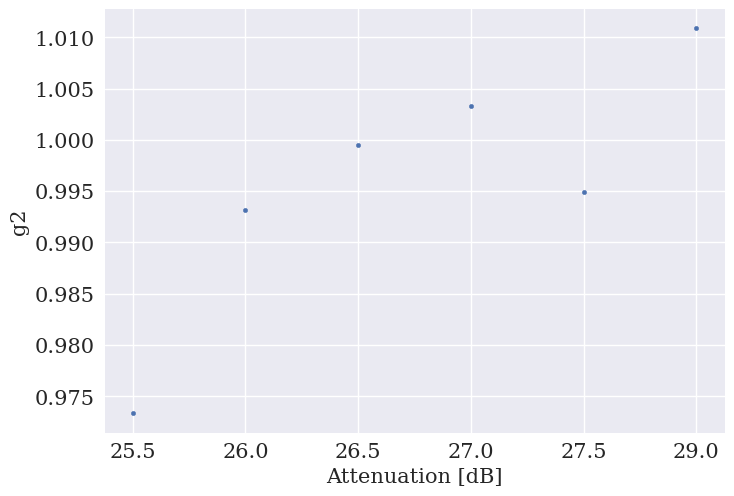

In [19]:
name_method = 'KPCA RBF'
gm = gaussian_mixture(X_l_KPCA_RBF,
                      data_test,
                      number_cluster = 25,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.1, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

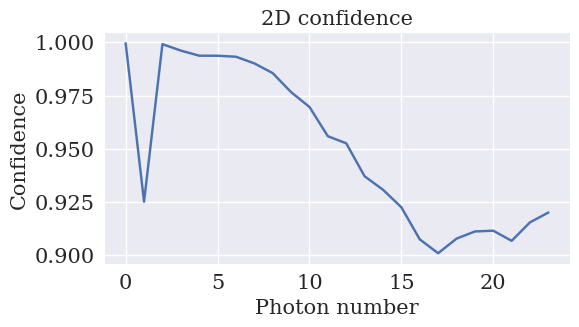

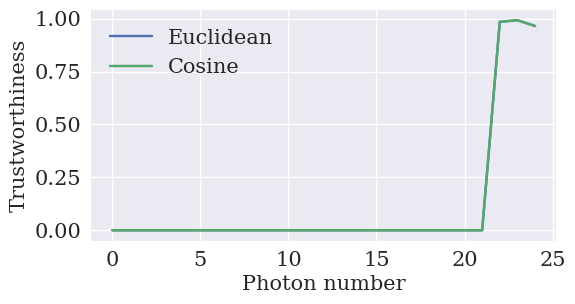

In [20]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Sigmoid)

In [21]:
X_l_KPCA_S = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="sigmoid",gamma=0.01) 

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


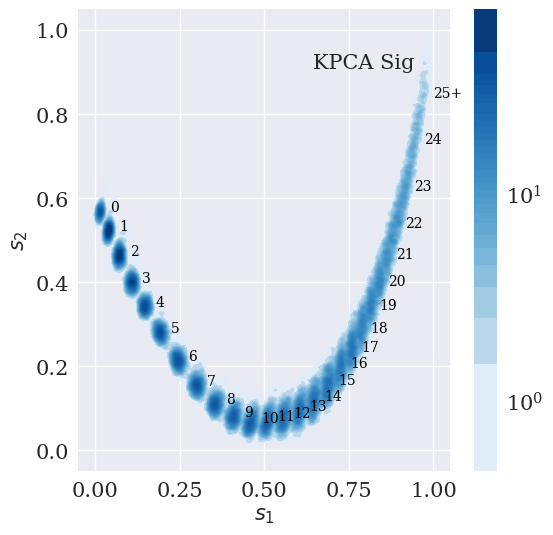

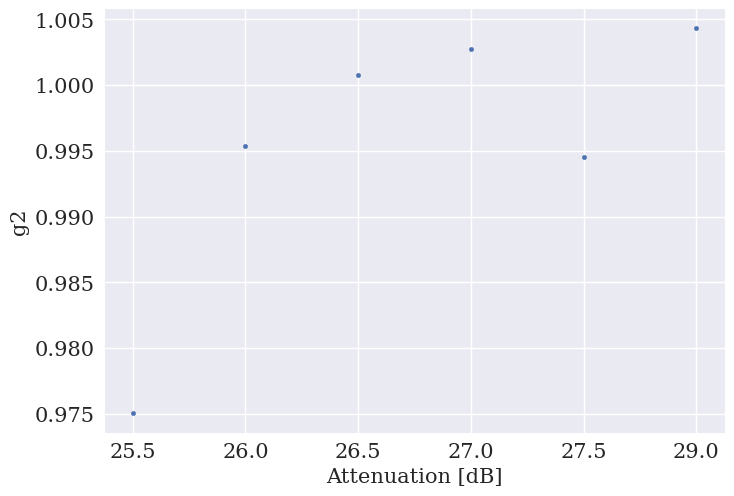

In [22]:
name_method = 'KPCA Sig'
gm = gaussian_mixture(X_l_KPCA_S,
                      data_test,
                      number_cluster = 26,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results))

gm.plot_density(bw_adjust = 0.1, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

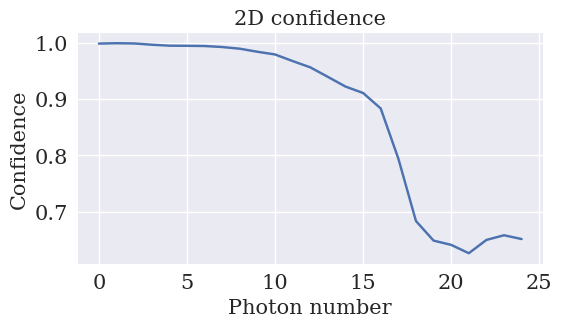

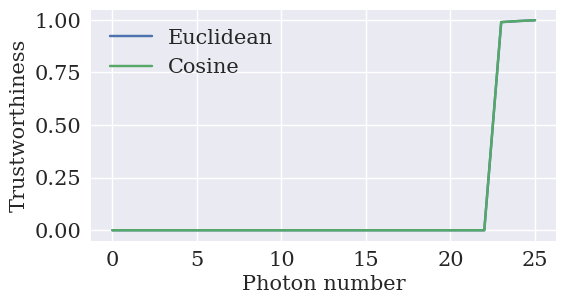

In [23]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Kernel PCA (Cosine)

In [24]:
X_l_KPCA_C = sklearn_available(data_train, data_test, path_save, KernelPCA,n_components=2,kernel="cosine",gamma=0.01) 

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


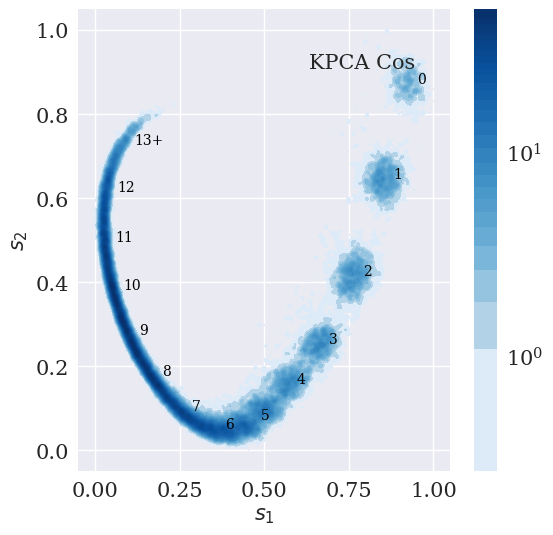

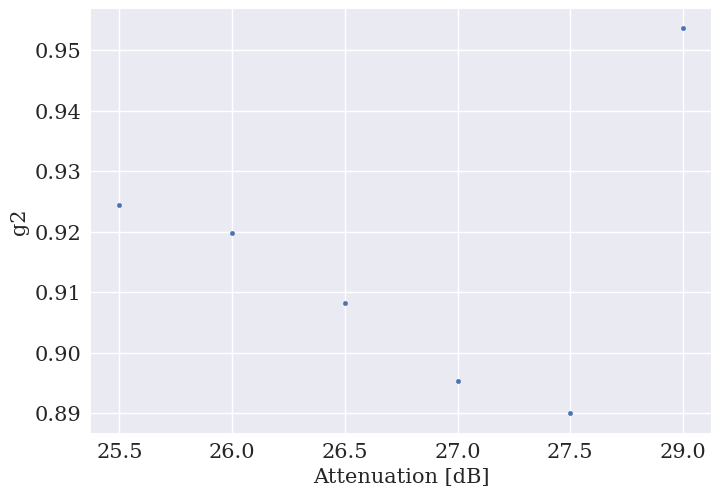

In [25]:
name_method = 'KPCA Cos'
gm = gaussian_mixture(X_l_KPCA_C,
                      data_test,
                      number_cluster = 14,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results))

gm.plot_density(bw_adjust = 0.1, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

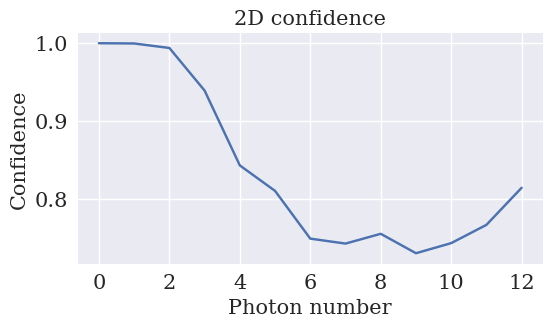

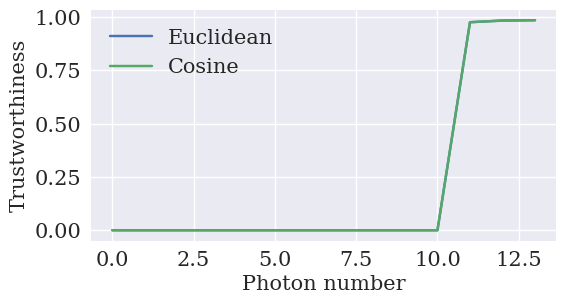

In [26]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### t-distributed Stochastic Neighbor Embedding (t-SNE)

In [6]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE,n_components=2, perplexity = 450)

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


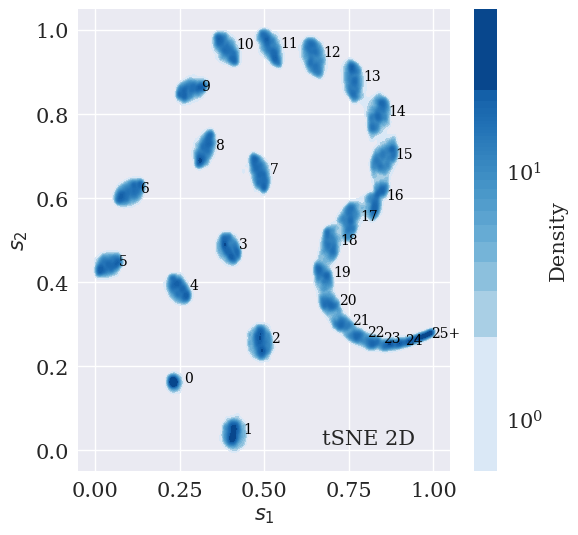

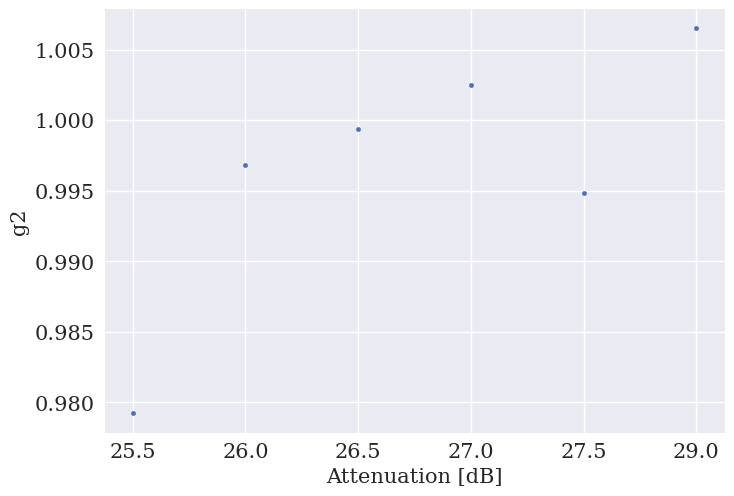

In [7]:
#%config InlineBackend.figure_formats=['svg']
name_method = 'tSNE 2D'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 26,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results))

gm.plot_density(bw_adjust = 0.1, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

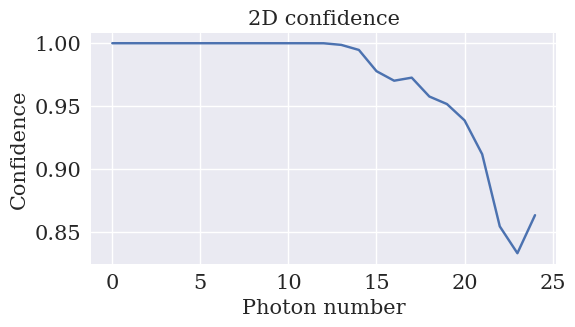

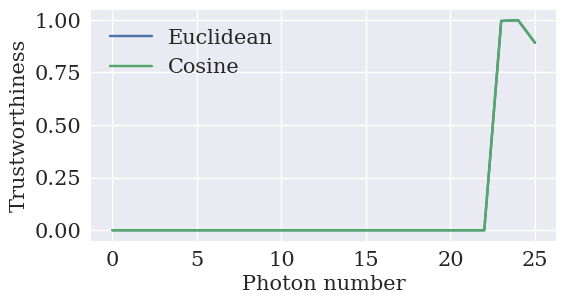

In [29]:
gm.plot_confidence_2d(expected_prob = expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [30]:
X_l_tSNE = sklearn_available(data_train, data_test, path_save, TSNE,n_components=1, perplexity = 450)

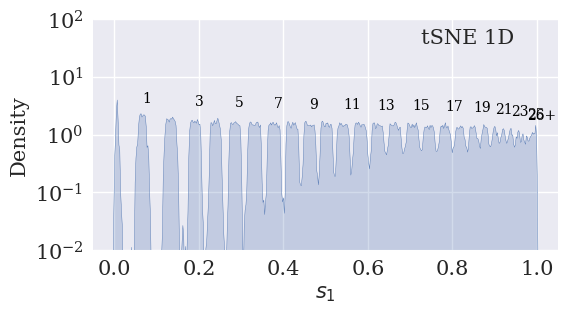

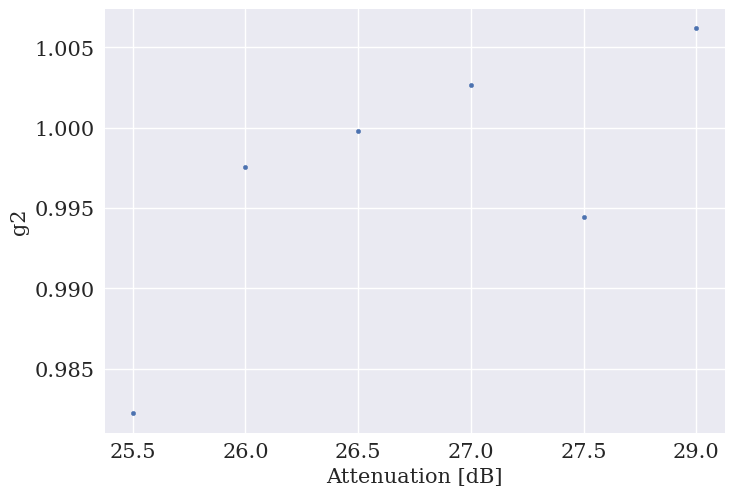

In [31]:
#%config InlineBackend.figure_formats=['svg']
name_method = 'tSNE 1D'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results))

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

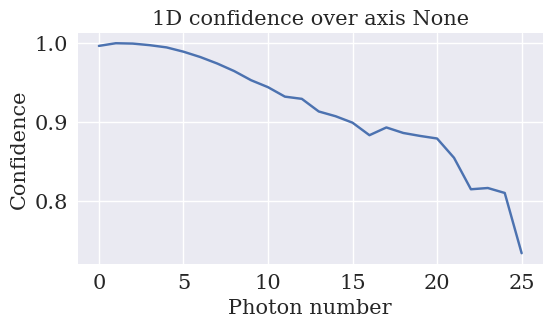

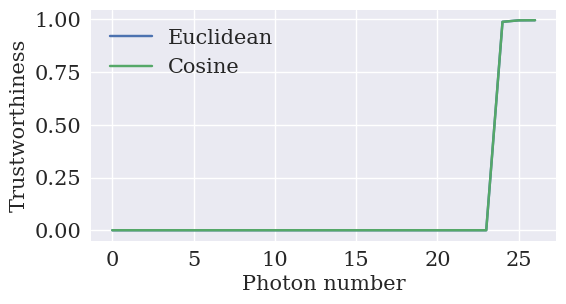

In [32]:
gm.plot_confidence_1d(expected_prob = expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

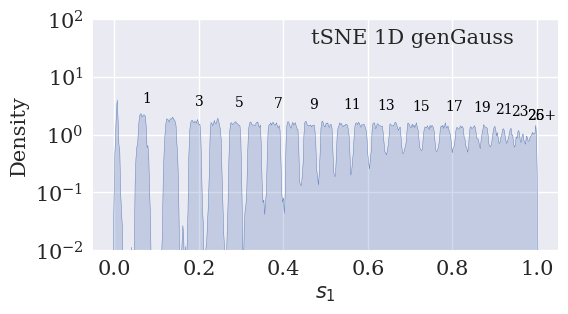

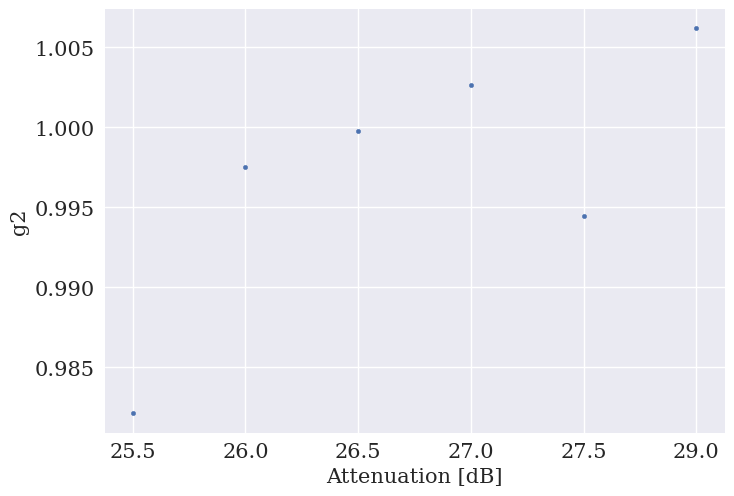

In [33]:
#%config InlineBackend.figure_formats=['svg']
name_method = 'tSNE 1D genGauss'
gm = gaussian_mixture(X_l_tSNE,
                      data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      tol = 1e-4,
                      means_init = get_means(name_method, path_results),
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

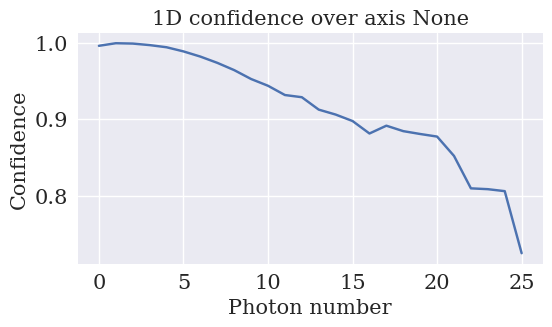

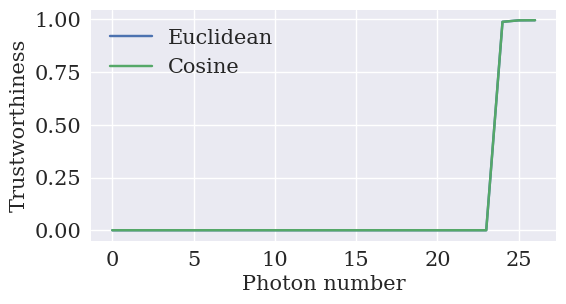

In [34]:
gm.plot_confidence_1d(expected_prob = expected_prob) 
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### UMAP

In [35]:
X_l_UMAP = sklearn_available(data_train, data_test, path_save+'/umap1d', umap.UMAP, '1000.npy', n_components=1, n_neighbors=1000)

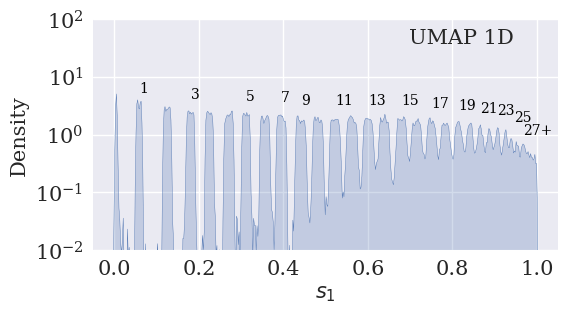

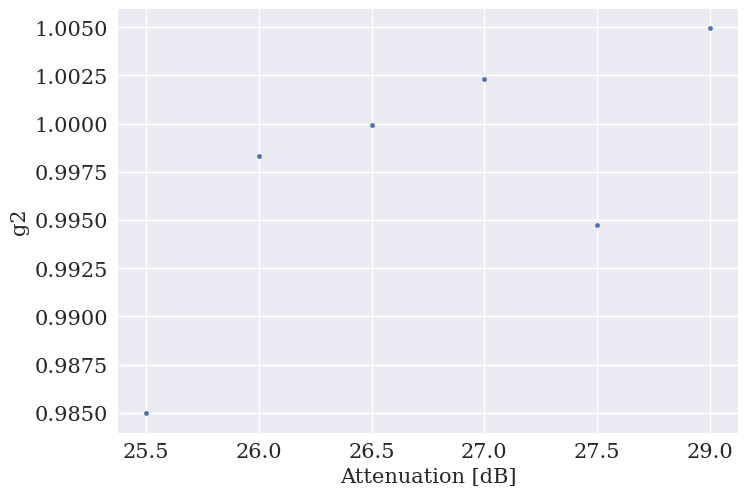

In [36]:
name_method = 'UMAP 1D'
gm = gaussian_mixture(X_low = X_l_UMAP,
                      X_high = data_test,
                      number_cluster = 28,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-4)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

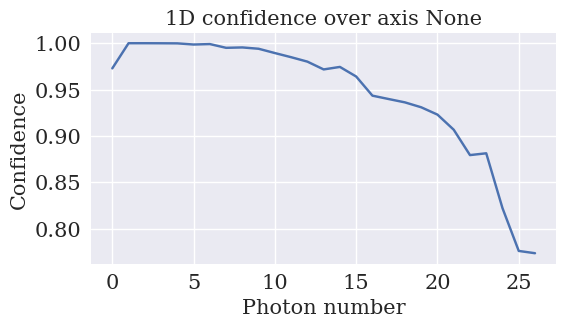

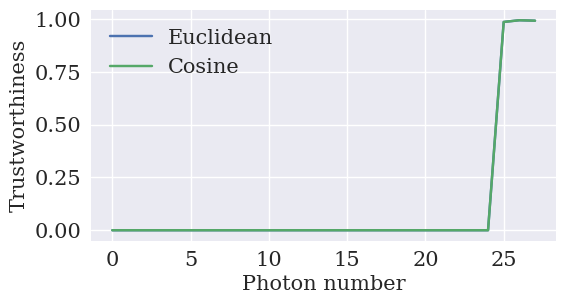

In [37]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [8]:
X_l_UMAP = sklearn_available(data_train, data_test, path_save+'/umap2d', umap.UMAP, '700.npy',n_components=2, n_neighbors=700)

/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


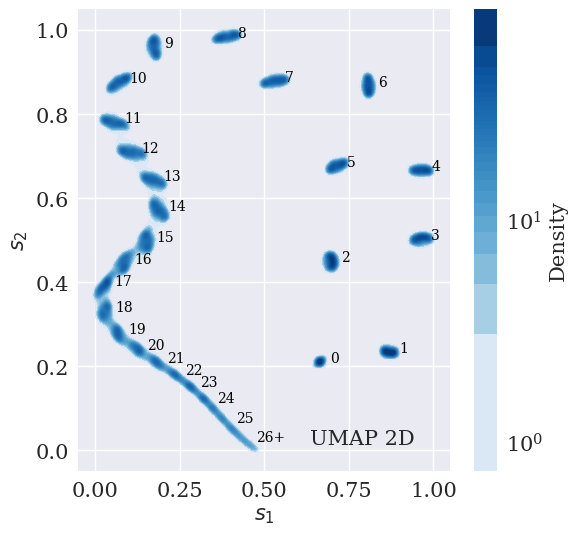

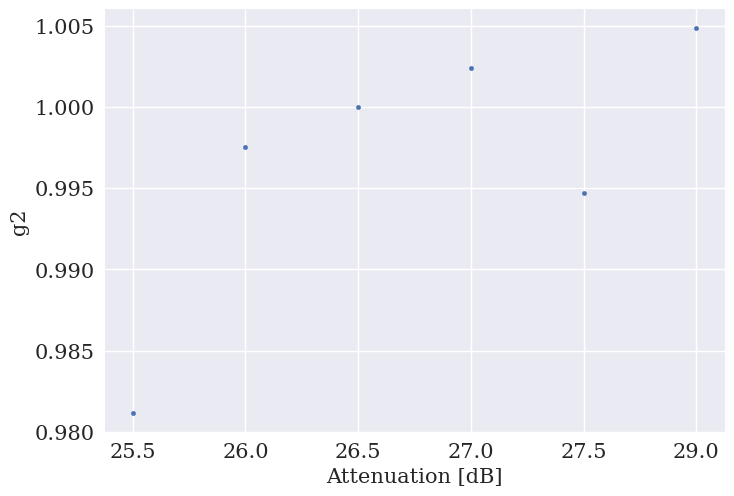

In [9]:
name_method = 'UMAP 2D'
gm = gaussian_mixture(X_low = X_l_UMAP,
                      X_high = data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-4)

gm.plot_density(bw_adjust = 0.1, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

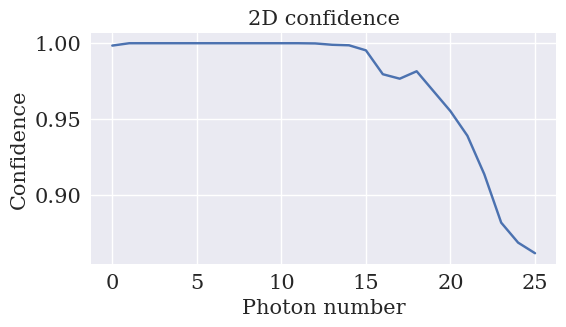

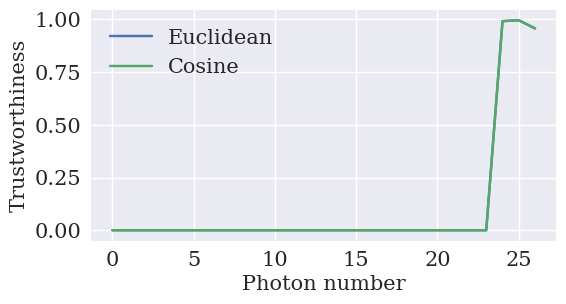

In [40]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Non-Negative Matrix Factorization (NMF)

In [41]:
X_l_NMF = sklearn_available(data_train, data_test, path_save, NMF,n_components=1, max_iter=400, solver='mu', beta_loss='kullback-leibler', tol=1e-10)

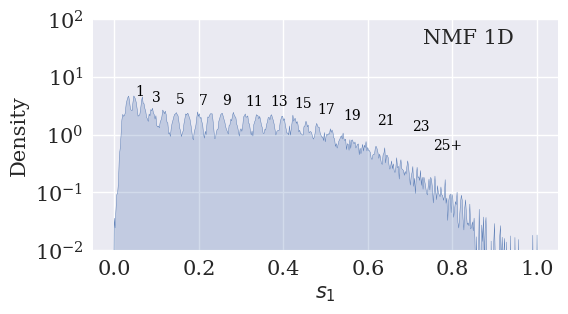

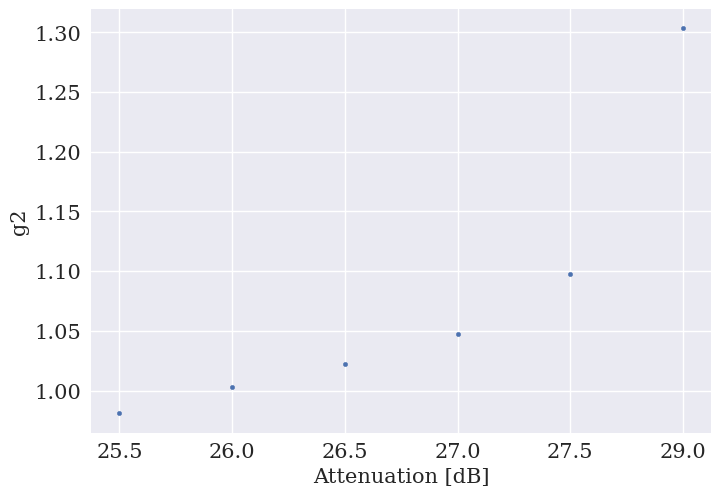

In [42]:
name_method = 'NMF 1D'
gm = gaussian_mixture(X_low = X_l_NMF,
                      X_high = data_test,
                      number_cluster = 26,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

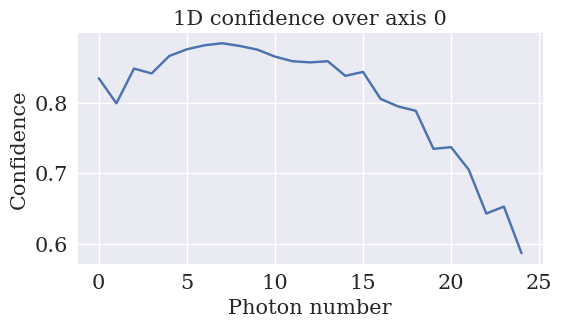

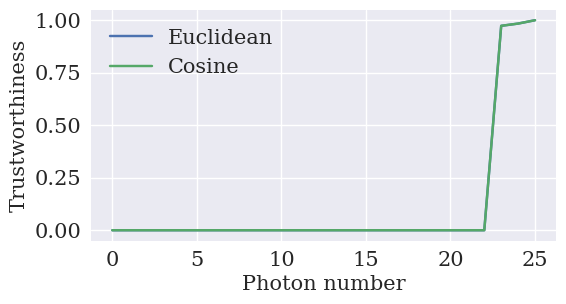

In [43]:
gm.plot_confidence_1d(expected_prob = expected_prob, axis=0)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Isomap

In [44]:
X_l_ISO = sklearn_available(data_train, data_test, path_save, Isomap, n_neighbors=15, n_components=1, eigen_solver="arpack")

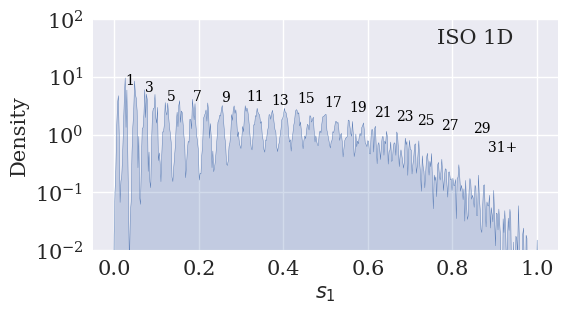

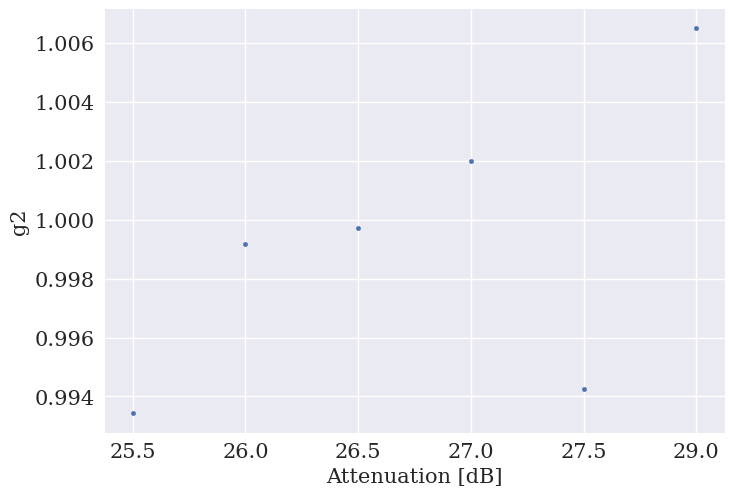

In [45]:
name_method = 'ISO 1D'
gm = gaussian_mixture(X_low = X_l_ISO,
                      X_high = data_test,
                      number_cluster = 32,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-4,
                      info_sweep = 0,
                      plot_sweep = True)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

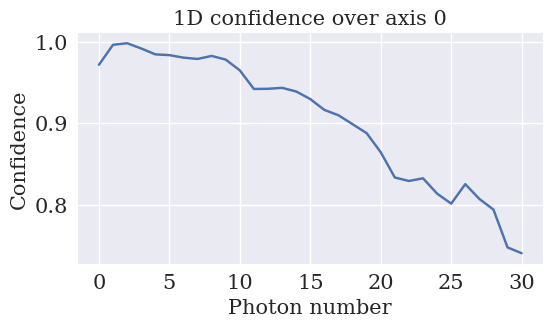

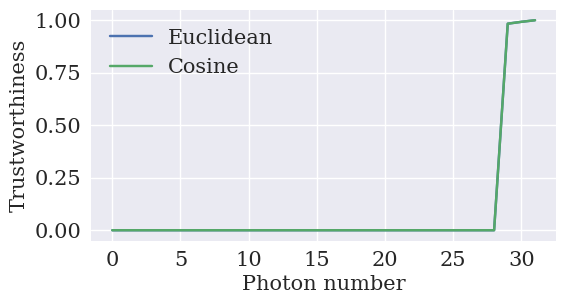

In [46]:
gm.plot_confidence_1d(expected_prob = expected_prob, axis=0)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Parametric t-SNE

In [11]:
import torch
from src.ParametricTSNE.train import load_model
from src.ParametricTSNE.model import Network

model = load_model(Network, f'src/ParametricTSNE/model 1D').to(device='cpu')

data_test_ = torch.from_numpy(data_test).float().view(-1, 350).to(device='cpu')
data_test_ = (data_test_ - data_test_.min()) / (data_test_.max() - data_test_.min())


with torch.no_grad():
    X_l_PTSNE = model(data_test_, encode = True).cpu().numpy()

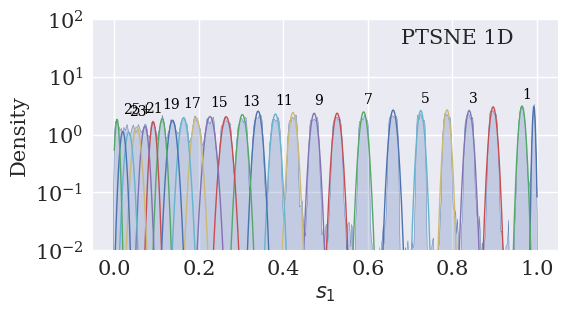

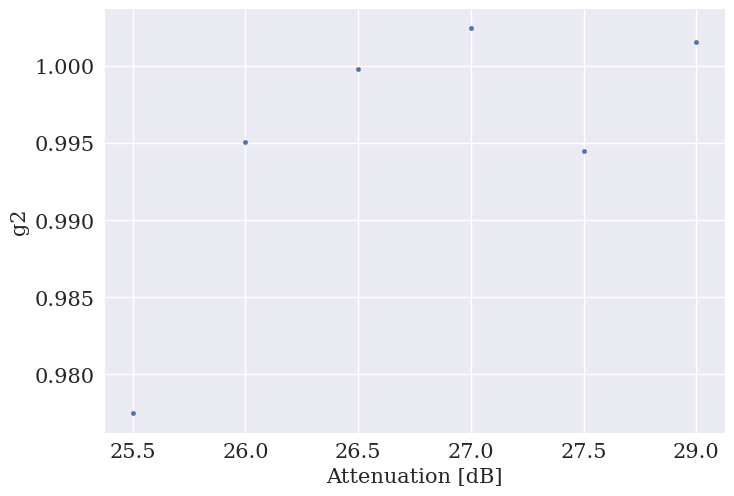

In [22]:
name_method = 'PTSNE 1D'
gm = gaussian_mixture(X_low = X_l_PTSNE,
                      X_high = data_test,
                      number_cluster = 26, 
                      cluster_iter = 5,
                      means_init = means,#get_means(name_method, path = path_results),
                      tol = 1e-4)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = True, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

In [21]:
import numpy as np
means = np.array([[0.99249444],
       [0.96456267],
       [0.89618501],
       [0.83944759],
       [0.78713704],
       [0.72498974],
       [0.65964762],
       [0.58984277],
       [0.52712788],
       [0.47279848],
       [0.42266733],
       [0.38120801],
       [0.34016701],
       [0.30293984],
       [0.26458849],
       [0.22653269],
       [0.19353721],
       [0.16395325],
       [0.13767466],
       [0.11330602],
       [0.09209708],
       [0.07231697],
       [0.05254894],
       [0.03395903],
       [0.01997153],
       [0.00653144]])

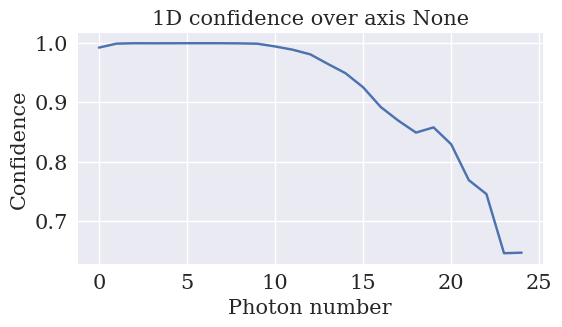

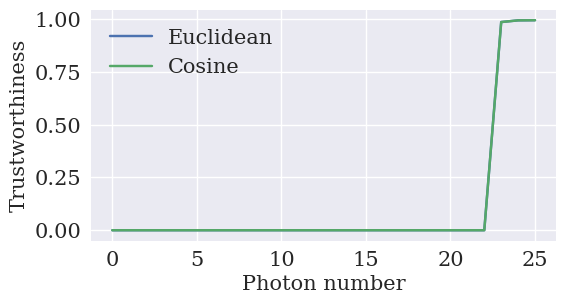

In [23]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

### Parametric UMAP

In [24]:
model = load_pumap(f'src/ParametricUMAP/model 1D/model.pt')

X_PUMAP = model.transform(torch.from_numpy(data_test).view(-1,350).to(dtype=torch.float)) 

Loading PUMAP object from pickled file.
Reducing array of shape torch.Size([30550, 350]) to (30550, 1)


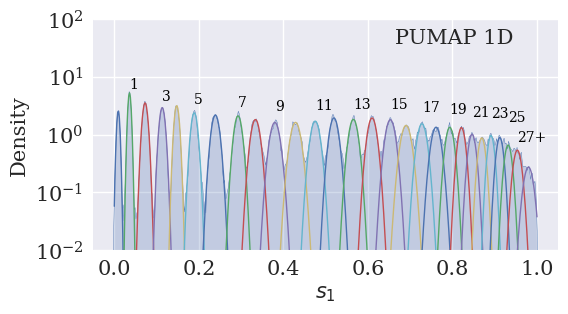

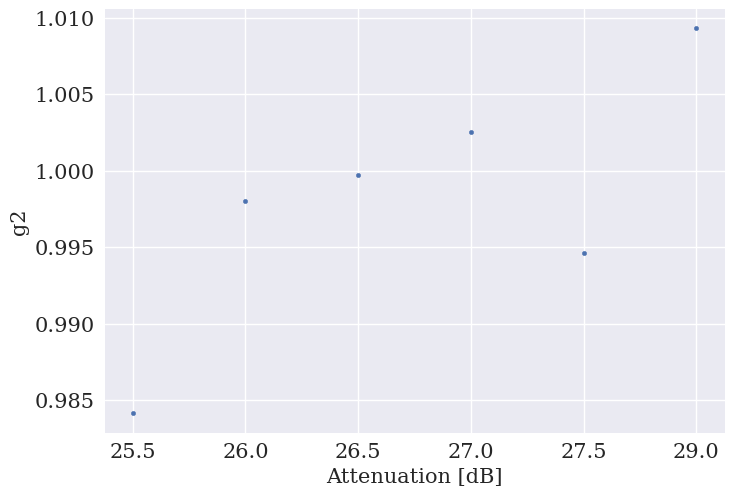

In [30]:
name_method = 'PUMAP 1D'
gm = gaussian_mixture(X_low = -X_PUMAP,
                      X_high = data_test,
                      number_cluster = 28,
                      cluster_iter = 5,
                      means_init = means,#1-get_means(name_method, path = path_results),
                      tol = 1e-4)

gm.plot_density(bw_adjust = 0.03, 
                plot_gaussians = True,
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

In [29]:
gm.remove_clusters([17])
means = gm.cluster_means

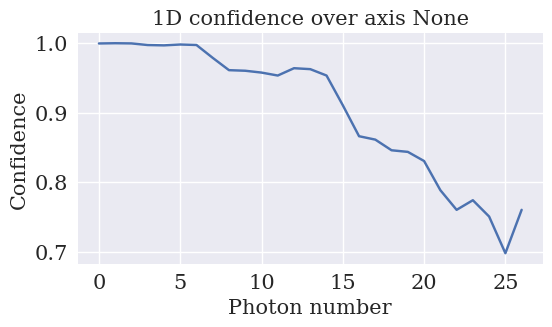

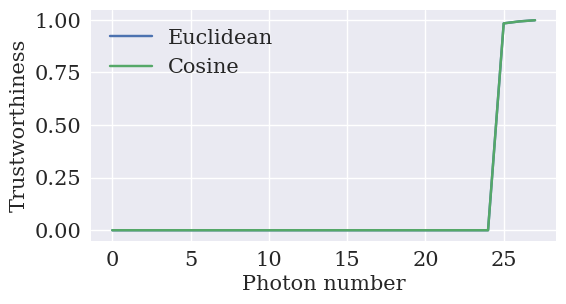

In [31]:
gm.plot_confidence_1d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)

In [53]:
model = load_pumap('test2d.pt')

X_PUMAP = model.transform(torch.from_numpy(data_test).view(-1,1,350).to(dtype=torch.float)) 

Loading PUMAP object from pickled file.
Reducing array of shape torch.Size([30550, 1, 350]) to (30550, 2)


/home/nicolasdc/anaconda3/envs/MLPytorch/lib/python3.10/site-packages/seaborn/distributions.py:1176: UserWarning: Log scale: values of z <= 0 have been masked
  cset = contour_func(


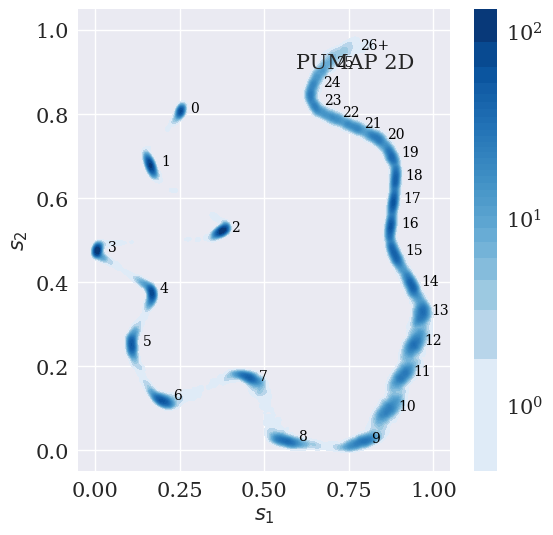

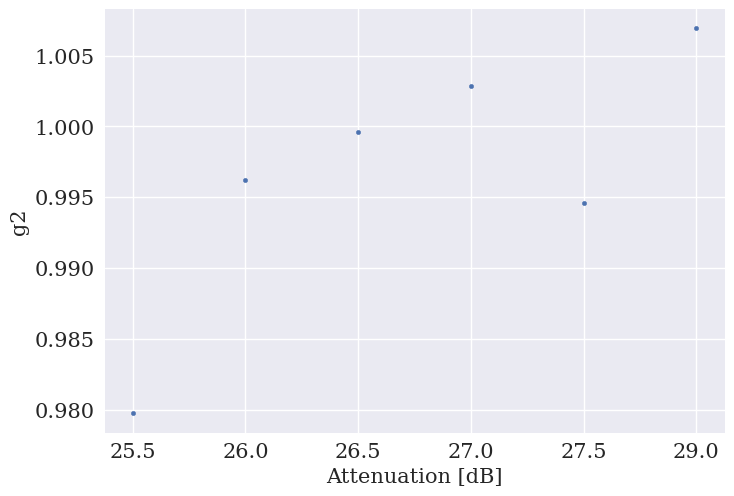

In [54]:
name_method = 'PUMAP 2D'
gm = gaussian_mixture(X_low = X_PUMAP,
                      X_high = data_test,
                      number_cluster = 27,
                      cluster_iter = 5,
                      means_init = get_means(name_method, path = path_results),
                      tol = 1e-3,
                      info_sweep = 0,
                      plot_sweep = False)

gm.plot_density(bw_adjust = 0.1,
                plot_gaussians = False, 
                text = name_method,
                save_path = 'src/Results TES (Uniform)/Density')
gm.plot_g2(db_test)

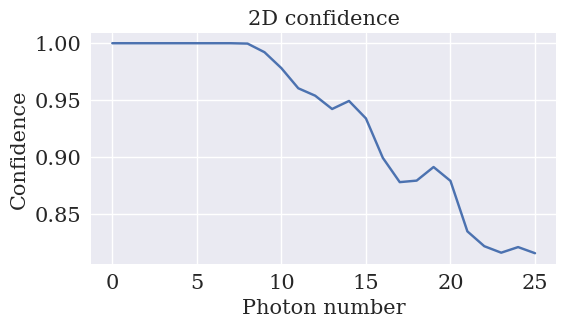

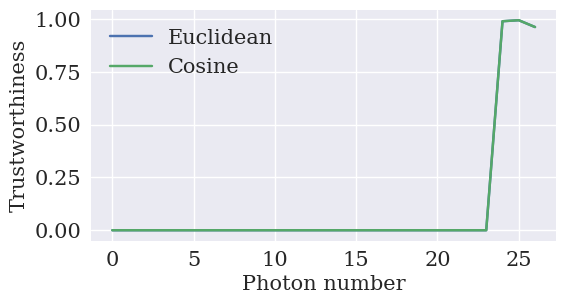

In [55]:
gm.plot_confidence_2d(expected_prob = expected_prob)
gm.plot_trustworthiness()
save_results(gm = gm, name_method = name_method, path = path_results)